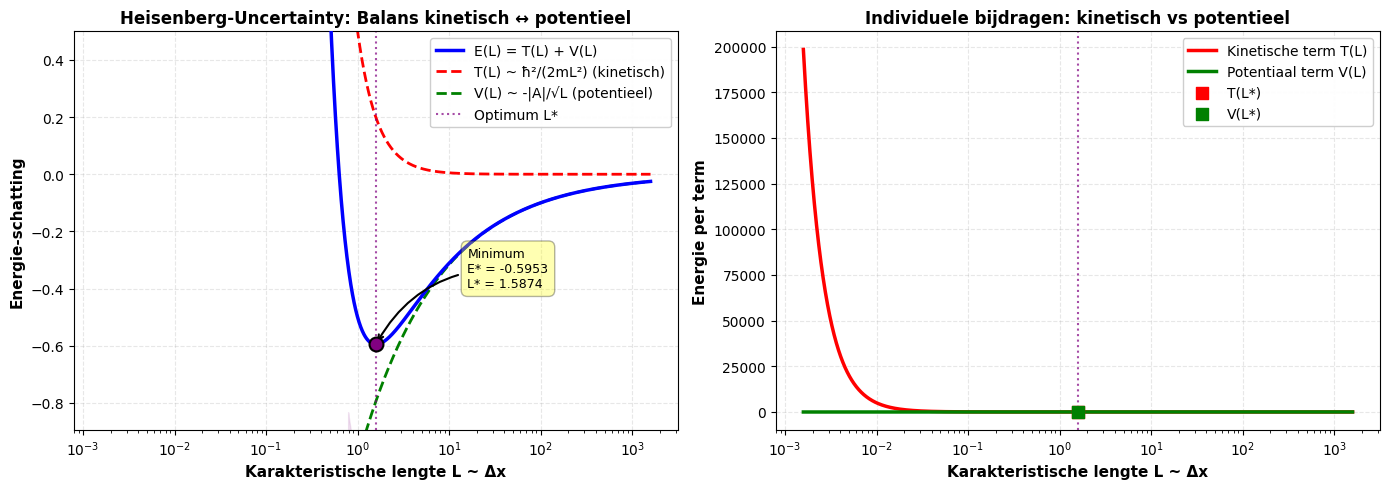


HEISENBERG UNCERTAINTY SCHATTING: V(x) = -|A|/√|x|

Parameters: A = 1.0, m = 1.0, ħ = 1.0

Analytische oplossing (exact uit energie-minimalisatie):
  L* = (2ħ²/mA)^(2/3) = 1.587401
  E* = -(3/2^(7/3)) * (mA⁴/ħ²)^(1/3) = -0.595275

Kinetische energie bij optimum:
  T(L*) = 0.198425

Potentiële energie bij optimum:
  V(L*) = -0.793701

Verificatie (virial-stelling): |V(L*)| / T(L*) = 4.000 (moet ≈ 2)

Numeriek minimum (op grid):
  L_min ≈ 1.592896
  E_min ≈ -0.595272
  Verschil E* - E_min = 3.54e-06



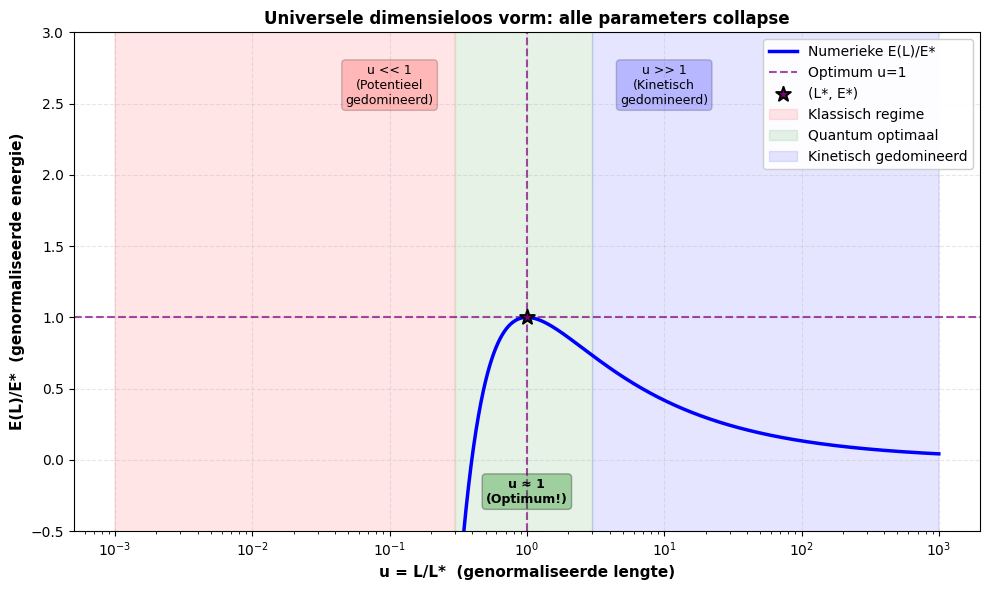


DIMENSIONSLOOS ANALYSE: Universele curve
Bij u=1 (optimum): E/E* = 1.0000000000
  Dit moet exact 1 zijn (numerieke afwijking: 2.22e-16)

De curve is ONAFHANKELIJK van A, m, ħ!
Dit is een universele wet van de Heisenberg-schatting.



In [3]:
import numpy as np
import matplotlib.pyplot as plt

def E_of_L(L, A=1.0, m=1.0, hbar=1.0):
    """Uncertainty-schatting: E(L)=ħ²/(2mL²) - |A|/sqrt(L).  L>0."""
    A = abs(A)
    return (hbar**2)/(2*m*L**2) - A/np.sqrt(L)

def T_of_L(L, m=1.0, hbar=1.0):
    return (hbar**2)/(2*m*L**2)

def V_of_L(L, A=1.0):
    return -abs(A)/np.sqrt(L)

def L_star(A=1.0, m=1.0, hbar=1.0):
    """Analytisch minimum."""
    A = abs(A)
    return (2*hbar**2/(m*A))**(2/3)

def E_star(A=1.0, m=1.0, hbar=1.0):
    """Analytische minimale energie (Heisenberg-schatting)."""
    A = abs(A)
    return -(3/(2**(7/3))) * (m**(1/3)) * (A**(4/3)) / (hbar**(2/3))

def plot_energy_landscape(A=1.0, m=1.0, hbar=1.0, span_decades=3.0, N=2000):
    """Verbeterde visualisatie van het energie-landschap met subplots."""
    Ls = L_star(A, m, hbar)
    L = np.logspace(np.log10(Ls) - span_decades, np.log10(Ls) + span_decades, N)

    E = E_of_L(L, A, m, hbar)
    T = T_of_L(L, m, hbar)
    V = V_of_L(L, A)
    Es = E_star(A, m, hbar)

    # Numeriek minimum
    i_min = np.argmin(E)
    L_min_num = L[i_min]
    E_min_num = E[i_min]

    # Figuur met 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # === PLOT 1: Totale energie + componenten ===
    ax1.plot(L, E, 'b-', linewidth=2.5, label='E(L) = T(L) + V(L)', zorder=3)
    ax1.plot(L, T, 'r--', linewidth=2, label='T(L) ~ ħ²/(2mL²) (kinetisch)', zorder=2)
    ax1.plot(L, V, 'g--', linewidth=2, label='V(L) ~ -|A|/√L (potentieel)', zorder=2)
    
    # Markeer optima
    ax1.axvline(Ls, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label='Optimum L*')
    ax1.scatter([Ls], [Es], s=100, color='purple', marker='o', zorder=5, edgecolors='black', linewidth=1.5)
    
    # Shading rond minimum
    idx_min_region = (L > Ls/2) & (L < Ls*2)
    ax1.fill_between(L[idx_min_region], E[idx_min_region]-0.5, -10, alpha=0.1, color='purple')
    
    ax1.set_xscale("log")
    ax1.set_xlabel("Karakteristische lengte L ~ Δx", fontsize=11, fontweight='bold')
    ax1.set_ylabel("Energie-schatting", fontsize=11, fontweight='bold')
    ax1.set_title("Heisenberg-Uncertainty: Balans kinetisch ↔ potentieel", fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10, loc='best', framealpha=0.95)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_ylim([Es-0.3, 0.5])
    
    # Annotatie bij optimum
    ax1.annotate(f'Minimum\nE* = {Es:.4f}\nL* = {Ls:.4f}',
                xy=(Ls, Es), xytext=(Ls*10, Es+0.2),
                fontsize=9, ha='left',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', lw=1.5))
    
    # === PLOT 2: Aparte weergave van T en V ===
    ax2.plot(L, T, 'r-', linewidth=2.5, label='Kinetische term T(L)', zorder=3)
    ax2.plot(L, V, 'g-', linewidth=2.5, label='Potentiaal term V(L)', zorder=3)
    ax2.axvline(Ls, color='purple', linestyle=':', linewidth=1.5, alpha=0.7)
    ax2.scatter([Ls], [T_of_L(Ls, m, hbar)], s=80, color='red', marker='s', zorder=5, label='T(L*)')
    ax2.scatter([Ls], [V_of_L(Ls, A)], s=80, color='green', marker='s', zorder=5, label='V(L*)')
    
    ax2.set_xscale("log")
    ax2.set_xlabel("Karakteristische lengte L ~ Δx", fontsize=11, fontweight='bold')
    ax2.set_ylabel("Energie per term", fontsize=11, fontweight='bold')
    ax2.set_title("Individuele bijdragen: kinetisch vs potentieel", fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10, loc='best', framealpha=0.95)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()

    # Uitgebreide print-output
    print("\n" + "="*70)
    print("HEISENBERG UNCERTAINTY SCHATTING: V(x) = -|A|/√|x|")
    print("="*70)
    print(f"\nParameters: A = {A}, m = {m}, ħ = {hbar}")
    print(f"\nAnalytische oplossing (exact uit energie-minimalisatie):")
    print(f"  L* = (2ħ²/mA)^(2/3) = {Ls:.6f}")
    print(f"  E* = -(3/2^(7/3)) * (mA⁴/ħ²)^(1/3) = {Es:.6f}")
    print(f"\nKinetische energie bij optimum:")
    print(f"  T(L*) = {T_of_L(Ls, m, hbar):.6f}")
    print(f"\nPotentiële energie bij optimum:")
    print(f"  V(L*) = {V_of_L(Ls, A):.6f}")
    print(f"\nVerificatie (virial-stelling): |V(L*)| / T(L*) = {abs(V_of_L(Ls, A)) / T_of_L(Ls, m, hbar):.3f} (moet ≈ 2)")
    print(f"\nNumeriek minimum (op grid):")
    print(f"  L_min ≈ {L_min_num:.6f}")
    print(f"  E_min ≈ {E_min_num:.6f}")
    print(f"  Verschil E* - E_min = {abs(Es - E_min_num):.2e}")
    print("="*70 + "\n")

def plot_dimensionless_collapse(A=1.0, m=1.0, hbar=1.0, umin=1e-3, umax=1e3, N=2000):
    """Verbeterde visualisatie van universele vorm."""
    Ls = L_star(A, m, hbar)
    Es = E_star(A, m, hbar)

    u = np.logspace(np.log10(umin), np.log10(umax), N)
    L = u * Ls
    E = E_of_L(L, A, m, hbar)
    
    # Theoretische vorm (voor referentie)
    E_theory = Es * (u**(-2) - 2**(2/3)*u**(-0.5))

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot numerieke curve
    ax.plot(u, E/Es, 'b-', linewidth=2.5, label='Numerieke E(L)/E*', zorder=3)
    
    # Markeer optimum
    ax.axvline(1.0, color='purple', linestyle='--', linewidth=1.5, alpha=0.7, label='Optimum u=1')
    ax.axhline(1.0, color='purple', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.scatter([1.0], [1.0], s=120, color='purple', marker='*', zorder=5, 
              edgecolors='black', linewidth=1.5, label='(L*, E*)')
    
    # Highlight verschillende regimes
    ax.fill_between(u[u < 0.3], -5, 10, alpha=0.1, color='red', label='Klassisch regime')
    ax.fill_between(u[(u > 0.3) & (u < 3)], -5, 10, alpha=0.1, color='green', label='Quantum optimaal')
    ax.fill_between(u[u > 3], -5, 10, alpha=0.1, color='blue', label='Kinetisch gedomineerd')
    
    ax.set_xscale("log")
    ax.set_xlabel("u = L/L*  (genormaliseerde lengte)", fontsize=11, fontweight='bold')
    ax.set_ylabel("E(L)/E*  (genormaliseerde energie)", fontsize=11, fontweight='bold')
    ax.set_title("Universele dimensieloos vorm: alle parameters collapse", fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best', framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([-0.5, 3])
    
    # Annotaties voor regimes
    ax.text(0.1, 2.5, "u << 1\n(Potentieel\ngedomineerd)", fontsize=9, ha='center',
           bbox=dict(boxstyle='round', facecolor='red', alpha=0.2))
    ax.text(1.0, -0.3, "u ≈ 1\n(Optimum!)", fontsize=9, ha='center', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))
    ax.text(10, 2.5, "u >> 1\n(Kinetisch\ngedomineerd)", fontsize=9, ha='center',
           bbox=dict(boxstyle='round', facecolor='blue', alpha=0.2))
    
    plt.tight_layout()
    plt.show()

    print("\n" + "="*70)
    print("DIMENSIONSLOOS ANALYSE: Universele curve")
    print("="*70)
    print(f"Bij u=1 (optimum): E/E* = {E_of_L(Ls, A, m, hbar)/Es:.10f}")
    print(f"  Dit moet exact 1 zijn (numerieke afwijking: {abs(E_of_L(Ls, A, m, hbar)/Es - 1):.2e})")
    print("\nDe curve is ONAFHANKELIJK van A, m, ħ!")
    print("Dit is een universele wet van de Heisenberg-schatting.")
    print("="*70 + "\n")

# === Voorbeeld run ===
plot_energy_landscape(A=1.0, m=1.0, hbar=1.0)
plot_dimensionless_collapse(A=1.0, m=1.0, hbar=1.0)